In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Merge commonly used dataframes
sf_product  = sales_fact.merge(product_dim,  on='product_id')
sf_customer = sales_fact.merge(customer_dim, on='customer_id')
sf_date     = sales_fact.merge(date_dim,     on='date_id')

In [6]:
import pandas as pd

sales_fact   = pd.read_csv('sales_fact.csv')
customer_dim = pd.read_csv('customer_dim.csv')
product_dim  = pd.read_csv('product_dim.csv')
date_dim     = pd.read_csv('date_dim.csv')

print(sales_fact.shape)
print(sales_fact.head())

(60, 6)
   sale_id  customer_id  product_id  date_id  quantity  revenue
0        1            1           2        1         2    59.98
1        2            1           1        1         1  1299.99
2        3            2           7        2         1    59.99
3        4            2           3        2         1    89.99
4        5            3           4        3         2   159.98


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

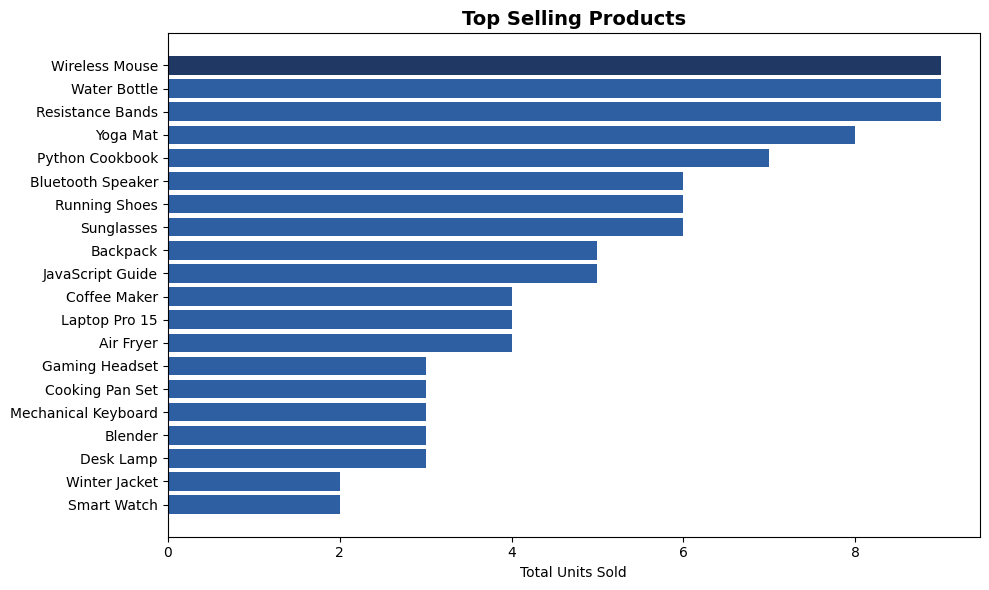

In [8]:
# Merge sales with product names
top_products = sales_fact.merge(product_dim, on='product_id')
top_products = top_products.groupby('product_name')['quantity'].sum().reset_index()
top_products = top_products.sort_values('quantity', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1F3864' if i == len(top_products)-1 else '#2E5FA3'
          for i in range(len(top_products))]
ax.barh(top_products['product_name'], top_products['quantity'], color=colors)
ax.set_xlabel('Total Units Sold')
ax.set_title('Top Selling Products', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_products.png', dpi=150)
plt.show()

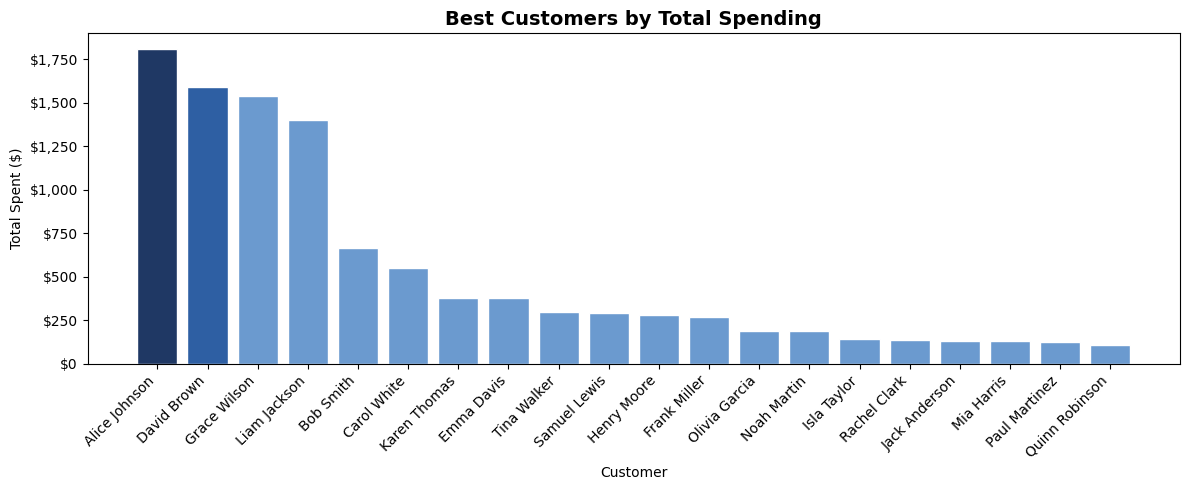

In [16]:
best_customers = sf_customer.groupby(['name', 'city'])['revenue'].sum().reset_index()
best_customers = best_customers.sort_values('revenue', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#1F3864' if i == 0 else '#2E5FA3' if i == 1 else '#6B9ACF'
          for i in range(len(best_customers))]
ax.bar(best_customers['name'], best_customers['revenue'],
       color=colors, edgecolor='white')
ax.set_title('Best Customers by Total Spending', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer')
ax.set_ylabel('Total Spent ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('best_customers.png', dpi=150)
plt.show()

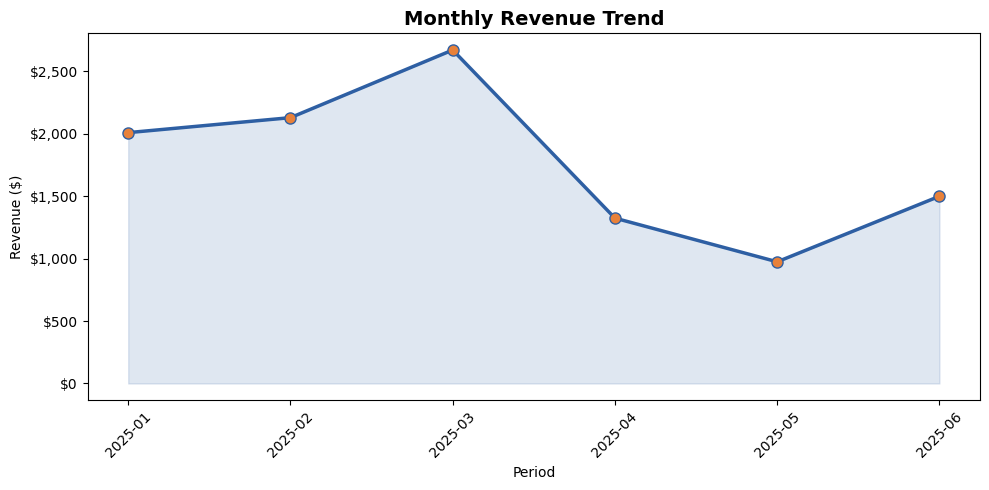

In [9]:
monthly = sales_fact.merge(date_dim, on='date_id')
monthly = monthly.groupby(['year', 'month'])['revenue'].sum().reset_index()
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly['period'], monthly['revenue'],
        marker='o', linewidth=2.5, color='#2E5FA3',
        markerfacecolor='#E8813A', markersize=8)
ax.fill_between(monthly['period'], monthly['revenue'], alpha=0.15, color='#2E5FA3')
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Period')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()

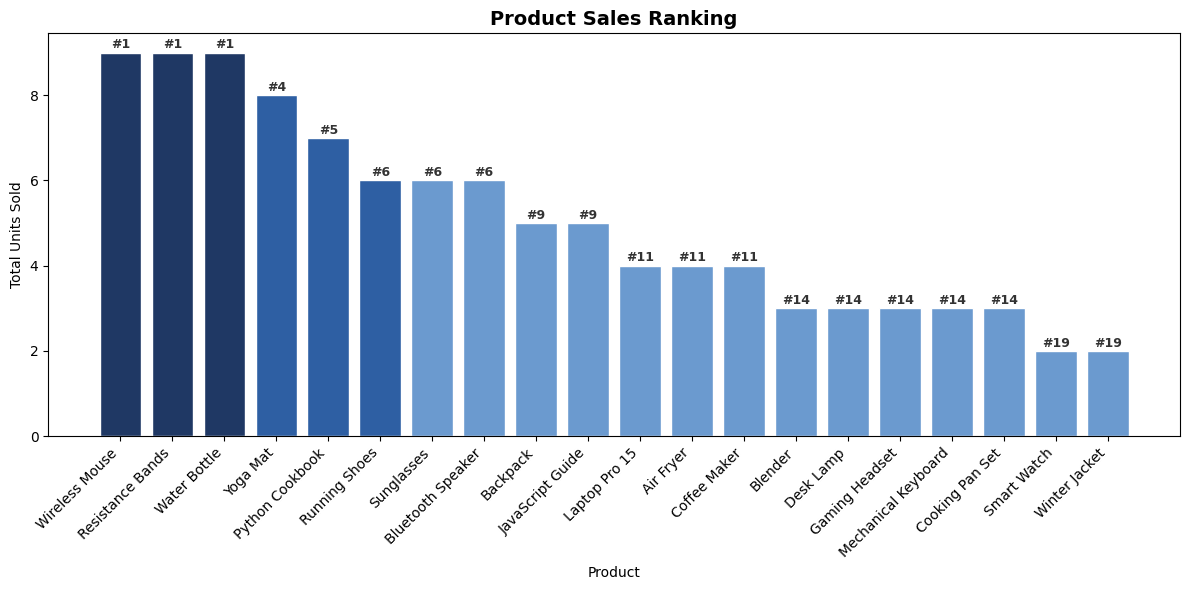

In [17]:
product_rank = sf_product.groupby(['product_name', 'category'])['quantity'].sum().reset_index()
product_rank = product_rank.sort_values('quantity', ascending=False).reset_index(drop=True)
product_rank['rank'] = product_rank['quantity'].rank(ascending=False, method='min').astype(int)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(product_rank['product_name'], product_rank['quantity'],
              color=['#1F3864' if i < 3 else '#2E5FA3' if i < 6 else '#6B9ACF'
                     for i in range(len(product_rank))],
              edgecolor='white')
for bar, rank in zip(bars, product_rank['rank']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'#{rank}',
            ha='center', fontsize=9, fontweight='bold', color='#333333')
ax.set_title('Product Sales Ranking', fontsize=14, fontweight='bold')
ax.set_xlabel('Product')
ax.set_ylabel('Total Units Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('product_ranking.png', dpi=150)
plt.show()

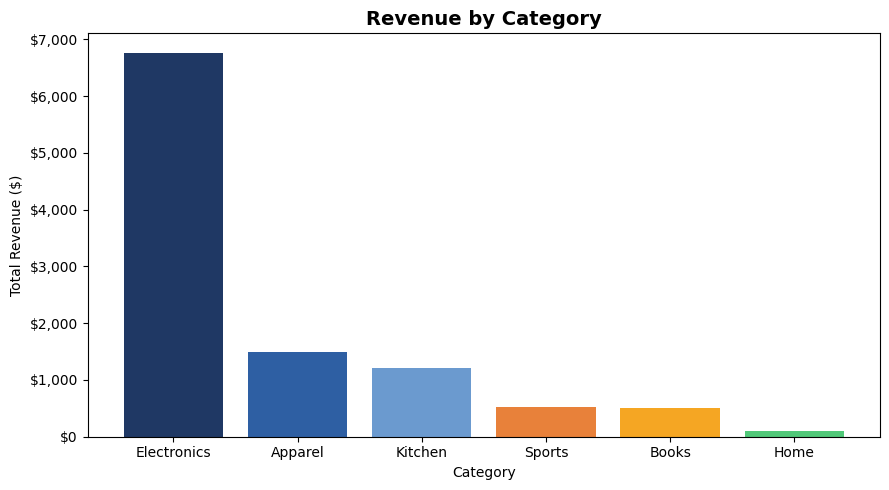

In [11]:
category = sales_fact.merge(product_dim, on='product_id')
category = category.groupby('category')['revenue'].sum().reset_index()
category = category.sort_values('revenue', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1F3864','#2E5FA3','#6B9ACF','#E8813A','#F5A623','#50C878']
ax.bar(category['category'], category['revenue'], color=colors[:len(category)])
ax.set_title('Revenue by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('category_revenue.png', dpi=150)
plt.show()

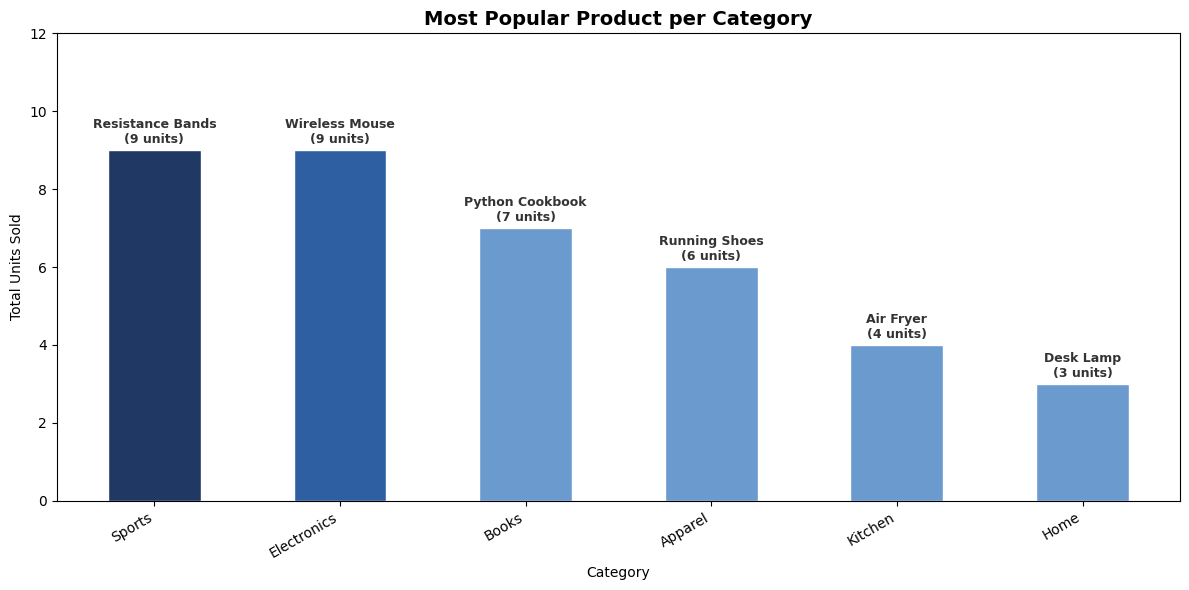

In [18]:
top_per_category = sf_product.groupby(
    ['category', 'product_name'])['quantity'].sum().reset_index()
top_per_category = top_per_category.loc[
    top_per_category.groupby('category')['quantity'].idxmax()
].sort_values('quantity', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_per_category['category'],
              top_per_category['quantity'],
              color=colors[:len(top_per_category)],
              edgecolor='white', width=0.5)
for bar, (_, row) in zip(bars, top_per_category.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{row['product_name']}\n({int(row['quantity'])} units)",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#333333')
ax.set_title('Most Popular Product per Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Units Sold')
ax.set_ylim(0, top_per_category['quantity'].max() + 3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('top_product_per_category.png', dpi=150)
plt.show()